In [1]:
import numpy as np
import pandas as pd
import skfuzzy as fuzz
from skfuzzy import control as ctrl
import matplotlib.pyplot as plt
%matplotlib inline

In [2]:
df = pd.read_csv('./fan-speed-data.csv')
percentage = 0.3
df.head()

,Temperature_C,TempLabel,Humidity_pct,HumidityLabel,Discomfort,FanSpeed,FanSpeedLabel
0,23.24,Comfortable,74.50,Humid,1.250,15.17,Low
1,31.31,Hot,34.37,Dry,7.310,88.72,High
2,28.25,Hot,28.69,Dry,4.250,51.58,Medium
3,26.38,Hot,49.37,Normal,2.380,28.89,Low
4,20.18,Comfortable,79.14,Humid,4.403,53.44,Medium


In [3]:
df.describe()

,Temperature_C,Humidity_pct,Discomfort,FanSpeed
count,150.000000,150.000000,150.000000,150.000000
mean,24.620200,51.051600,3.788420,45.981200
std,4.151553,17.484636,2.104343,25.540941
min,18.080000,20.300000,0.022000,0.260000
25%,21.005000,34.850000,1.941250,23.560000
50%,24.270000,53.360000,3.783000,45.910000
75%,28.497500,65.472500,5.425250,65.847500
max,31.820000,79.400000,8.239000,100.000000


In [5]:
temperature = ctrl.Antecedent(np.linspace(18, 32, 141), 'Temperature_C')
humidity = ctrl.Antecedent(np.linspace(20, 80, 121), 'Humidity_pct')
fan_speed = ctrl.Consequent(np.linspace(0, 100, 101), 'FanSpeed')

In [6]:
temperature['Cold'] = fuzz.trimf(temperature.universe, [18, 18, 22])
temperature['Warm'] = fuzz.trimf(temperature.universe, [20, 25, 30])
temperature['Hot']  = fuzz.trimf(temperature.universe, [28, 32, 32])

humidity['Dry'] = fuzz.trimf(humidity.universe, [20, 20, 40])
humidity['Normal'] = fuzz.trimf(humidity.universe, [30, 50, 70])
humidity['Humid'] = fuzz.trimf(humidity.universe, [60, 80, 80])

fan_speed['Low'] = fuzz.trimf(fan_speed.universe, [0, 0, 40])
fan_speed['Medium'] = fuzz.trimf(fan_speed.universe, [30, 50, 70])
fan_speed['High'] = fuzz.trimf(fan_speed.universe, [60, 100, 100])

In [7]:
rule1 = ctrl.Rule(temperature['Cold'] & humidity['Dry'], fan_speed['Low'])
rule2 = ctrl.Rule(temperature['Warm'] & humidity['Normal'], fan_speed['Medium'])
rule3 = ctrl.Rule(temperature['Hot'] & humidity['Humid'], fan_speed['High'])
rule4 = ctrl.Rule(temperature['Hot'] & humidity['Normal'], fan_speed['High'])
rule5 = ctrl.Rule(temperature['Warm'] & humidity['Humid'], fan_speed['Medium'])
rule6 = ctrl.Rule(temperature['Cold'] & humidity['Humid'], fan_speed['Medium'])


In [8]:
fan_ctrl = ctrl.ControlSystem([rule1, rule2, rule3, rule4, rule5, rule6])
fan_sim = ctrl.ControlSystemSimulation(fan_ctrl)


In [19]:
def _derive_outputs_manual(temp_val, hum_val, fan_speed_val):
    temp_m = {
        'Cold': fuzz.interp_membership(temperature.universe, temperature['Cold'].mf, temp_val),
        'Warm': fuzz.interp_membership(temperature.universe, temperature['Warm'].mf, temp_val),
        'Hot': fuzz.interp_membership(temperature.universe, temperature['Hot'].mf, temp_val)
    }
    hum_m = {
        'Dry': fuzz.interp_membership(humidity.universe, humidity['Dry'].mf, hum_val),
        'Normal': fuzz.interp_membership(humidity.universe, humidity['Normal'].mf, hum_val),
        'Humid': fuzz.interp_membership(humidity.universe, humidity['Humid'].mf, hum_val)
    }

    if temp_m['Cold'] > temp_m['Warm'] and temp_m['Cold'] > temp_m['Hot']:
        temp_lbl = 'Cold'
    elif temp_m['Warm'] > temp_m['Hot']:
        temp_lbl = 'Warm'
    else:
        temp_lbl = 'Hot'

    if hum_m['Dry'] > hum_m['Normal'] and hum_m['Dry'] > hum_m['Humid']:
        hum_lbl = 'Dry'
    elif hum_m['Normal'] > hum_m['Humid']:
        hum_lbl = 'Normal'
    else:
        hum_lbl = 'Humid'

    if fan_speed_val < 35:
        fan_lbl = 'Low'
    elif fan_speed_val < 65:
        fan_lbl = 'Medium'
    else:
        fan_lbl = 'High'

    discomfort = temp_val - 0.55 * (1 - (hum_val / 100)) * (temp_val - 14.5)

    return fan_speed_val, temp_lbl, hum_lbl, fan_lbl, discomfort


In [22]:
def simulate_fan(Temperature_C, Humidity_pct):
    """
    Robust simulation: create a fresh ControlSystemSimulation per call
    and retrieve FanSpeed safely (no KeyError).
    Returns: (fan_val, temp_label, hum_label, fan_label, discomfort)
    """
    if 'fan_ctrl' not in globals():
        raise NameError("fan_ctrl belum didefinisikan. Jalankan kembali cell yang mendefinisikan rules & fan_ctrl.")

    sim = ctrl.ControlSystemSimulation(fan_ctrl)

    # set inputs
    sim.input['Temperature_C'] = float(Temperature_C)
    sim.input['Humidity_pct'] = float(Humidity_pct)

    # compute
    sim.compute()

    out = sim.output  # dict-like
    fan_speed_val = None

    if 'FanSpeed' in out:
        fan_speed_val = out['FanSpeed']
    else:
        if len(out) == 1:
            fan_speed_val = next(iter(out.values()))
        else:
            for v in out.values():
                try:
                    fan_speed_val = float(v)
                    break
                except Exception:
                    continue

    if fan_speed_val is None:
        fan_speed_val = float('nan')

    try:
        fan_speed_val = float(fan_speed_val)
    except Exception:
        fan_speed_val = float('nan')

    return _derive_outputs_manual(Temperature_C, Humidity_pct, fan_speed_val)

In [23]:
def process_csv(input_path, output_path):
    df = pd.read_csv(input_path)

    required_cols = {'Temperature_C', 'Humidity_pct'}
    if not required_cols.issubset(df.columns):
        raise ValueError(f"Input CSV must contain columns: {required_cols}")

    results = []
    for _, row in df.iterrows():
        fan_val, temp_lbl, hum_lbl, fan_lbl, discomfort = simulate_fan(
            row['Temperature_C'],
            row['Humidity_pct']
        )
        results.append([round(fan_val, 2), temp_lbl, hum_lbl, fan_lbl, round(discomfort, 2)])

    df[['FanSpeed', 'TempLabel', 'HumidityLabel', 'FanSpeedLabel', 'Discomfort']] = results
    df.to_csv(output_path, index=False)
    print(f"✅ Processed CSV saved as: {output_path}")
    return df


In [24]:
if __name__ == "__main__":
    df_out = process_csv("fan-speed-data.csv", "fan-speed-output.csv")
    display(df_out.head())

✅ Processed CSV saved as: fan-speed-output.csv


,Temperature_C,TempLabel,Humidity_pct,HumidityLabel,Discomfort,FanSpeed,FanSpeedLabel
0,23.24,Warm,74.50,Humid,22.01,50.0,Medium
1,31.31,Hot,34.37,Dry,25.24,82.1,High
2,28.25,Warm,28.69,Dry,22.86,NaN,High
3,26.38,Warm,49.37,Normal,23.07,50.0,Medium
4,20.18,Cold,79.14,Humid,19.53,50.0,Medium


In [25]:
def plot_results(df):
    plt.figure(figsize=(12,4))

    plt.subplot(1,3,1)
    plt.hist(df['FanSpeed'], bins=10, color='skyblue', edgecolor='black')
    plt.title('Distribusi FanSpeed')

    plt.subplot(1,3,2)
    df['FanSpeedLabel'].value_counts().plot(kind='bar', color='lightgreen')
    plt.title('Jumlah Label FanSpeed')

    plt.subplot(1,3,3)
    plt.scatter(df['Discomfort'], df['FanSpeed'], color='salmon')
    plt.xlabel('Discomfort')
    plt.ylabel('FanSpeed')
    plt.title('Discomfort vs FanSpeed')

    plt.tight_layout()
    plt.show()

✅ Processed CSV saved as: fan-speed-output.csv


,Temperature_C,TempLabel,Humidity_pct,HumidityLabel,Discomfort,FanSpeed,FanSpeedLabel
0,23.24,Warm,74.50,Humid,22.01,50.0,Medium
1,31.31,Hot,34.37,Dry,25.24,82.1,High
2,28.25,Warm,28.69,Dry,22.86,NaN,High
3,26.38,Warm,49.37,Normal,23.07,50.0,Medium
4,20.18,Cold,79.14,Humid,19.53,50.0,Medium


D:\Anaconda3\envs\lab_ai\Lib\site-packages\numpy\lib\_histograms_impl.py:842: RuntimeWarning: invalid value encountered in greater_equal
  keep = (tmp_a >= first_edge)
D:\Anaconda3\envs\lab_ai\Lib\site-packages\numpy\lib\_histograms_impl.py:843: RuntimeWarning: invalid value encountered in less_equal
  keep &= (tmp_a <= last_edge)


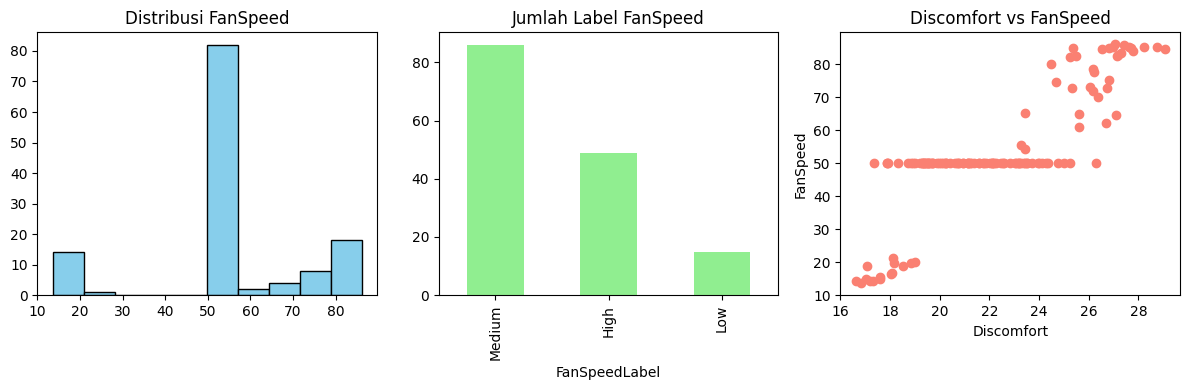

In [26]:
if __name__ == "__main__":
    df_out = process_csv("fan-speed-data.csv", "fan-speed-output.csv")
    display(df_out.head())
    plot_results(df_out)